In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import os
import pickle

### Plotting Utilities

In [2]:
# Set the ticks as functions of pi
def pi_formatter(x, pos):
    fractions = {0: '0', np.pi/4: r'$\pi/4$', np.pi/2: r'$\pi/2$', 
                 3*np.pi/4: r'$3\pi/4$', np.pi: r'$\pi$'}
    return fractions.get(x, f'{x/np.pi:.2g}π')


## Reading the data from simulations

*change the input directory and the logic to read data from other files*

In [3]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):

    directory = directory + '_mup_' + str(fixed_cof)
    
    os.chdir(directory)


    phi = np.zeros(len(aspect_ratios))
    phi_fluct = np.zeros(len(aspect_ratios))
    pdf_data = np.zeros((len(aspect_ratios), 100)) 

    angles = np.zeros((len(aspect_ratios), 100))


    for idx, ap in enumerate(aspect_ratios):
        os.chdir(f'Alpha{ap}')
        print(f"Reading data from directory: {os.getcwd()}")
        file_orientation = f'dir_ang_I{fixed_I}.dat'
        file_density = f"phi_E{ap}"
        converter = {0: lambda s:s.decode('utf-8')}
        if os.path.exists(file_orientation):
            orientations = np.loadtxt(file_orientation)
        else:
            raise FileNotFoundError(f"Orientation file {file_orientation} not found in {os.getcwd()}")

        angles[idx], pdf_data[idx] = get_pdf_from_symmetric_distribution(orientations) 

        if os.path.exists(file_density):
            density_data = np.genfromtxt(file_density, 
                                         dtype= object,
                                         encoding='utf-8', 
                                         converters={0: lambda s:s}) 
        else:
            raise FileNotFoundError(f"Density file {file_density} not found in {os.getcwd()}")
        os.chdir('..') # return to the original directory
        phi[idx], phi_fluct[idx] = process_density_data(density_data, fixed_I)

    os.chdir('..')  # return to the parent directory

    return angles, pdf_data, phi, phi_fluct


def get_pdf_from_symmetric_distribution(orientations):
    """
    Calculate the PDF from a symmetric distribution
    """

    try:
        if orientations.shape[0] % 2 ==0:
            half_idx = orientations.shape[0] // 2
            orientations[:half_idx, 2] += orientations[half_idx:, 2]
            orientations[:, 1] = np.deg2rad(orientations[:, 1])
    except IndexError:
            raise ValueError("The number of orientations must be even.")
        
    angles = orientations[:half_idx, 1] 
    angles -= np.pi/2  # Adjust angles to be centered around 0
    pdf = orientations[:half_idx, 2] 
    pdf = np.roll(pdf, half_idx//2)  # Shift the PDF to match the angles
    pdf = pdf[::-1]
    pdf /= np.trapezoid(pdf, angles)  # Normalize the PDF

    return angles, pdf 

def process_density_data(density_data, fixed_I):
    """
    Process the density data to extract phi and phi_fluct
    """
    numeric_data = [density_data[name].astype(float) for name in density_data.dtype.names[1:]]
    numeric_data = np.array(numeric_data).T  # Transpose to get columns as arrays
    
    I = str(fixed_I)

    idx_phi = np.where(density_data['f0'] == I)[0]
    phi = numeric_data[idx_phi, 2]
    phi_fluct = numeric_data[idx_phi, 3]

    return phi, phi_fluct


In [4]:
aspect_ratios = [1.025, 1.13, 1.246, 1.374, 1.515, 1.67, 1.842, 2.03, 2.238, 2.468, 2.721, 3.0]  
angles, pdf, phi, phi_fluct = read_pdf_theta('./inertial_dir', 0.0, 1, aspect_ratios)

Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.025
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.13
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.246
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.374
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.515
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.67
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha1.842
Reading data from directory: /home/jacopo/Documents/phd_research/Data_processing_orientations/inertial_dir_mup_0.0/Alpha

/tmp/ipykernel_25299/1350711717.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  phi[idx], phi_fluct[idx] = process_density_data(density_data, fixed_I)


In [5]:
os.chdir('/home/jacopo/Documents/phd_research/Data_processing_orientations/')

Text(0, 0.5, '$\\phi_{fluct}$')

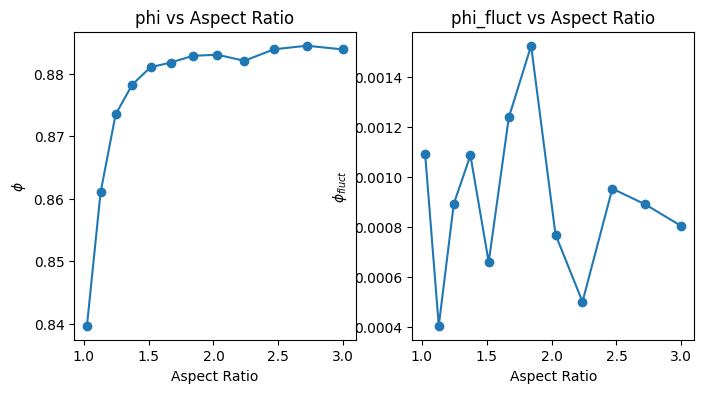

In [6]:
# fig, axes = plt.subplots(1, len(aspect_ratios), figsize=(4*len(aspect_ratios), 4), sharey=True)
# for idx, ax in enumerate(axes):
#     ax.set_title(f'Aspect Ratio: {aspect_ratios[idx]}')
#     ax.set_xlabel(r'$\theta$ (radians)')
#     ax.set_ylabel('PDF')
#     ax.xaxis.set_major_formatter(plt.FuncFormatter(pi_formatter))
    
#     # Plot the PDF
#     ax.plot(angles[idx], pdf[idx], label='PDF')
#     ax.legend()

fig2, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].set_title('phi vs Aspect Ratio')
ax[0].plot(aspect_ratios, phi, marker='o', label='phi')
ax[0].set_xlabel('Aspect Ratio')
ax[0].set_ylabel(r'$\phi$')
ax[1].set_title('phi_fluct vs Aspect Ratio')
ax[1].plot(aspect_ratios, phi_fluct, marker='o', label='phi_fluct')
ax[1].set_xlabel('Aspect Ratio')
ax[1].set_ylabel(r'$\phi_{fluct}$')


In [7]:
# Define the function to fit
def fit_function(x, r, theta_d):
    """ Model function with r and theta_d as parameters. """
    numerator = np.exp(r * np.cos(2 * (x - theta_d)))
    
    # Compute denominator numerically
    denominator, _ = spi.quad(lambda t: np.exp(r * np.cos(2 * (t - theta_d))), -np.pi/2, np.pi/2)
    
    return numerator / denominator

def performing_fit(aspect_ratios, angles, pdf):
    optimized_params = []
    for i, alpha in enumerate(aspect_ratios):
        intial_guess = [1.0, 0.0]  # Initial guess for r and theta_d
        popt, pcov = spo.curve_fit(fit_function, angles[i], pdf[i], p0=intial_guess)
        r = popt[0]
        theta_d = popt[1]
        x_fit = np.linspace(-np.pi/2, np.pi/2, 200)
        y_fit = fit_function(x_fit, r, theta_d)
        U = r / np.trapezoid(np.cos(2 * (x_fit - theta_d)) * y_fit, x_fit)

        beta = (alpha**2 - 1) / (alpha**2 + 1)    
        g_r = (np.trapezoid(np.exp(r*np.cos(2*x_fit)), x_fit)/np.pi)**2
        cos_2theta_d = 2 * np.cos(theta_d) ** 2 - 1
        strength = (U / (r * beta)) * ((1 - 1 / g_r) / cos_2theta_d) 

        optimized_params.append({'alpha': alpha, 'r': r, 'theta_d': theta_d, 'U': U, 'g_r': g_r, 'strength': strength})

    return optimized_params
                                


In [8]:
fit_params = performing_fit(aspect_ratios, angles, pdf)

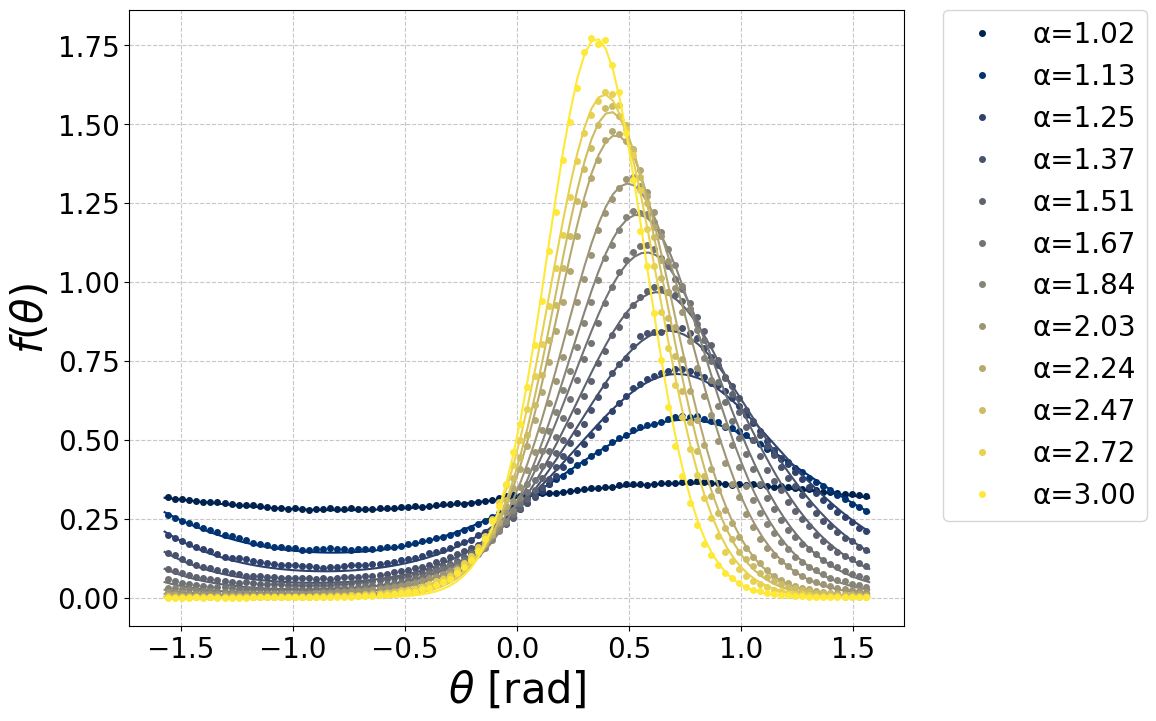

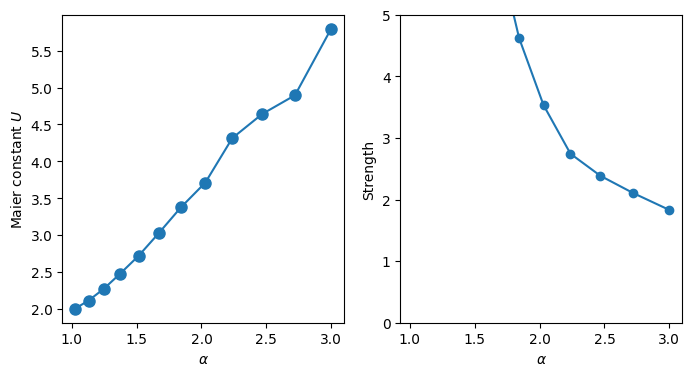

In [9]:
# Plot the actual data and fits
plt.figure(figsize=(10, 8))
colormap = plt.cm.cividis
colors = [colormap(i) for i in np.linspace(0, 1, len(aspect_ratios))]

for i, result in enumerate(fit_params):
    alpha = result['alpha']
    r = result['r']
    theta_d = result['theta_d']
    
    # Generate model predictions
    x_fit = np.linspace(-np.pi/2, np.pi/2, 100)
    y_fit = fit_function(x_fit, r, theta_d)
    
    
    plt.plot(angles[i], pdf[i], 'o', markersize=4, label=f"α={alpha:.2f}", color=colors[i])
    
    # Plot fitted function
    plt.plot(x_fit, y_fit, '-', color=colors[i]) #label=f"Fit (α={alpha:.2f})",

plt.xlabel('$\\theta$ [rad]', fontsize=30)
plt.ylabel('$f(\\theta)$', fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('Fit of the Circular PDF', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend(fontsize=30, loc='outside')
plt.legend(fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.savefig('fit_maier_2d_granular.pdf', bbox_inches='tight', dpi=300)
plt.show()

# plot U as a function of alpha
alphas = [result['alpha'] for result in fit_params]
Us = [result['U'] for result in fit_params]
strengths = [result['strength'] for result in fit_params]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(alphas, Us, 'o-', markersize=8)
axes[0].set_xlabel('$\\alpha$')
axes[0].set_ylabel('Maier constant $U$')
axes[1].plot(alphas, strengths, 'o-')
axes[1].set_xlabel('$\\alpha$')
axes[1].set_ylabel('Strength')
axes[1].set_ylim(0, 5)
plt.show()



In [10]:
import numpy as np
from scipy.integrate import quad

def K_schlacken(omega, k):
    # K(omega) integral definition
    def integrand(t):
        cos_w, sin_w = np.cos(omega), np.sin(omega)
        cos_t, sin_t = np.cos(t), np.sin(t)
        term1 = (cos_w * cos_t - k * sin_w * sin_t)**2
        term2 = ((sin_w * cos_t / k) + cos_w * sin_t)**2
        return np.sqrt(term1 + term2)
    
    integral, _ = quad(integrand, 0, 2 * np.pi, limit=200)
    return integral / (2 * np.pi)

def excluded_area_second_coefficient(k, num_pts=1000):
    """
    Computes the second Fourier coefficient (cos(2θ)) of the excluded area
    between two hard ellipses with aspect ratio k.
    
    Returns: A2 / A_p (normalized by particle area)
    """
    omegas = np.linspace(0, 2 * np.pi, num_pts, endpoint=False)
    K_vals = np.array([K_schlacken(omega, k) for omega in omegas])
    
    cos2w = np.cos(2 * omegas)
    integrand = K_vals * cos2w
    
    A2_norm = (1 / (2 * np.pi)) * np.trapezoid(integrand, omegas)
    return A2_norm

excluded_areas = [excluded_area_second_coefficient(ap) for ap in aspect_ratios]


<>:31: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_25299/363604525.py:31: SyntaxWarning: invalid escape sequence '\,'
  plt.axhline(y=1, color='r', linestyle='--', label='$U/(2 \\eta(\\phi) \, A_2) = 1$')


(0.0, 5.0)

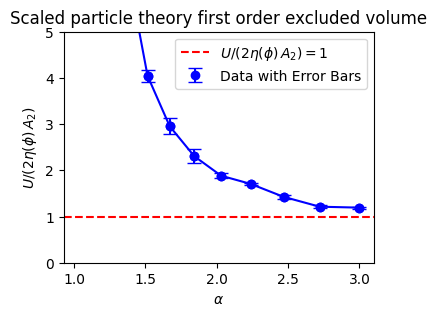

In [11]:
# density_correction = -np.log(phi) + phi / (1-phi)
density_correction = - np.log(1-phi) + phi / (1-phi)
density_correction = 1/2 * (3 / (1-phi) + np.log(1-phi) - 3) #parsonslike


derivative = phi*(2-phi)/ (1-phi)**2 # need to double check
fluct_correction_spt =  derivative * phi_fluct


excluded_areas = np.array(excluded_areas)
positive_excluded_areas =  -excluded_areas  


plt.figure(figsize=(4, 3))
plt.plot(aspect_ratios, Us/(2*density_correction*positive_excluded_areas), marker='o', color = 'blue')
# plt.plot(aspect_ratios, 2*density_correction*positive_excluded_areas, label='2 * $\\eta(\\phi) \\, A_2$', linestyle='--')
# add error bars for phi_fluct
plt.errorbar(aspect_ratios, Us/(2*density_correction*positive_excluded_areas), 
             yerr=fluct_correction_spt/(density_correction*positive_excluded_areas), 
             fmt='o', capsize=5, label='Data with Error Bars', color = 'blue')

# plt.errorbar(aspect_ratios, Us, 
#              yerr=fluct_correction_spt, 
#              fmt='o', capsize=5, label='Data with Error Bars')


plt.xlabel('$\\alpha$')
plt.title('Scaled particle theory first order excluded volume')
plt.ylabel(r'$U/(2 \eta(\phi) \, A_2)$')
# plt.ylabel(r'$U$')
plt.axhline(y=1, color='r', linestyle='--', label='$U/(2 \\eta(\\phi) \, A_2) = 1$')
plt.savefig('scaled_particle_theory_first_order_excluded_volume.pdf', bbox_inches='tight', dpi=300)
plt.legend()
plt.ylim(0, 5)

In [12]:
print(excluded_areas)

[-0.00111429 -0.00380155 -0.01007917 -0.01996922 -0.03347983 -0.0506038
 -0.07157389 -0.09613732 -0.12466717 -0.15730022 -0.19402214 -0.23510477]
